# Task 3: Multimodal ML — Housing Price Prediction Using Images + Tabular Data

**Objective:**
Predict housing prices by combining two very different input types in one
model:
- **Tabular/structured data** — bedrooms, bathrooms, square footage, zip code
- **Images** — photos of the bedroom, bathroom, kitchen, and house frontal
  view

A Convolutional Neural Network (CNN) extracts visual features from the
images, a small dense network (MLP) processes the tabular features, and the
two feature sets are **fused (concatenated)** before a final regression head
predicts the price. This is trained and evaluated end-to-end in one model.

**Tools and Technologies:**
- Python 3
- pandas, numpy — tabular data handling
- OpenCV (`cv2`) — image loading/resizing
- TensorFlow / Keras — CNN branch, MLP branch, fusion, and training
- scikit-learn — train/test split, feature scaling, one-hot encoding,
  MAE/RMSE evaluation
- matplotlib — visualizing training curves and prediction quality

**Dataset:**
Ahmed & Moustafa "Houses Dataset" — the standard public benchmark for this
exact task (used in the well-known Keras multi-input regression tutorial).
GitHub: https://github.com/emanhamed/Houses-dataset

It contains **535 houses**. Each house has:
- 4 images: bedroom, bathroom, kitchen, and frontal (exterior) view
- 1 row of tabular data in `HousesInfo.txt`: `bedrooms bathrooms area zipcode price`

**Skills Gained:**
- Multimodal machine learning
- Convolutional Neural Networks (CNNs)
- Feature fusion (image + tabular)
- Regression modeling and evaluation (MAE, RMSE)

**Important info before running:** this notebook downloads the dataset with
`git clone` in Step 2, so you need an internet connection the first time you
run it. If `git` isn't available in your environment, download the dataset
ZIP manually from the GitHub link above, unzip it, and place the
`Houses-dataset` folder next to this notebook.


## Step 1: Import Libraries

**Purpose:** Load everything we'll need — tabular handling, image loading,
scikit-learn preprocessing/metrics, and the Keras layers used to build the
CNN branch, MLP branch, and the fused regression model.

In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelBinarizer
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Conv2D, MaxPooling2D, BatchNormalization,
    Flatten, Dropout, concatenate
)

IMG_SIZE = 32          # each individual room photo is resized to 32x32
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Step 2: Download the Dataset

**Purpose:** Clone the Houses Dataset repository, which contains the
`Houses Dataset` folder with all 2,140 images (535 houses x 4 images) and
`HousesInfo.txt` with the matching tabular data.

**Dataset link:** https://github.com/emanhamed/Houses-dataset

In [2]:
if not os.path.exists("Houses-dataset"):
    os.system("git clone --depth 1 https://github.com/emanhamed/Houses-dataset.git")
else:
    print("Dataset already downloaded.")

DATASET_DIR = "Houses-dataset/Houses Dataset"
print("Files in dataset dir:", len(os.listdir(DATASET_DIR)))

Files in dataset dir: 2141


## Step 3: Load the Tabular Data

**Purpose:** `HousesInfo.txt` is a space-separated file with no header, one
row per house: `bedrooms bathrooms area zipcode price`. We load it into a
DataFrame and set the index to 1, 2, 3... to match how the image files are
named (e.g. house 1's images are `1_bedroom.jpg`, `1_bathroom.jpg`, etc.).

In [3]:
cols = ["bedrooms", "bathrooms", "area", "zipcode", "price"]
df = pd.read_csv(os.path.join(DATASET_DIR, "HousesInfo.txt"), sep=" ", header=None, names=cols)
df.index = np.arange(1, len(df) + 1)   # 1-based, matches image filename prefixes

print(f"Loaded {len(df)} houses")
df.head()

Loaded 535 houses


,bedrooms,bathrooms,area,zipcode,price
1,4,4.0,4053,85255,869500
2,4,3.0,3343,36372,865200
3,3,4.0,3923,85266,889000
4,5,5.0,4022,85262,910000
5,3,4.0,4116,85266,971226


## Step 4: Remove Houses with Rare Zip Codes

**Purpose:** We'll one-hot encode `zipcode` as a categorical feature. If a
zip code appears in only 1-2 houses, it can end up only in the training set
or only in the test set, which breaks one-hot encoding consistency and gives
the model almost nothing to learn from that category. Standard practice
(and what the dataset's own benchmark papers do) is to drop houses whose zip
code appears fewer than 5 times.

In [4]:
zip_counts = df["zipcode"].value_counts()
rare_zips = zip_counts[zip_counts < 5].index
df = df[~df["zipcode"].isin(rare_zips)]

house_indices = df.index.to_numpy()
print(f"Shape after removing rare zip codes: {df.shape}")
print(f"Remaining unique zip codes: {df['zipcode'].nunique()}")

Shape after removing rare zip codes: (487, 5)
Remaining unique zip codes: 18


## Step 5: Build an Image "Montage" for Each House

**Purpose:** Each house has 4 separate photos. Instead of building 4 separate
CNN input branches (more complex), we use the common, simpler technique from
the original tutorial this dataset was built for: tile the 4 photos
(bathroom, bedroom, frontal, kitchen) into a single 2x2 grid image. This
gives the CNN one combined image per house that still shows all 4 rooms,
which it can process with one convolutional branch.

Each individual photo is resized to 32x32 before tiling, so the final
montage image is 64x64x3.

In [5]:
def load_house_montage(idx, base_dir=DATASET_DIR, size=IMG_SIZE):
    image_types = ["bathroom", "bedroom", "frontal", "kitchen"]
    imgs = []
    for t in image_types:
        path = os.path.join(base_dir, f"{idx}_{t}.jpg")
        img = cv2.imread(path)
        img = cv2.resize(img, (size, size))
        imgs.append(img)
    top = np.hstack([imgs[0], imgs[1]])       # bathroom | bedroom
    bottom = np.hstack([imgs[2], imgs[3]])    # frontal  | kitchen
    montage = np.vstack([top, bottom])
    return montage

print("Building montages for all houses (this takes a little while)...")
images = np.array([load_house_montage(i) for i in house_indices], dtype="float32") / 255.0
print("Images array shape:", images.shape)  # (num_houses, 64, 64, 3)

Building montages for all houses (this takes a little while)...
Images array shape: (487, 64, 64, 3)


## Step 6: Visualize a Sample Montage

**Purpose:** Sanity-check that the montage building worked correctly — each
tile should be a real photo of that house's rooms, not a black/broken
image.

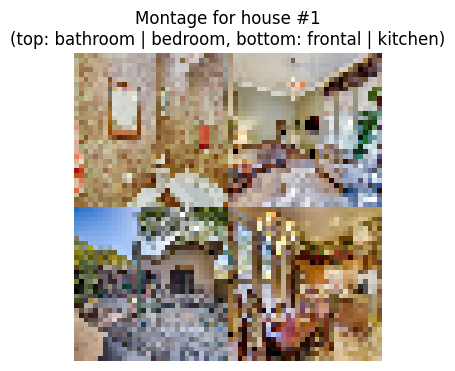

In [6]:
sample_idx = 0
plt.figure(figsize=(4, 4))
plt.imshow(cv2.cvtColor((images[sample_idx] * 255).astype("uint8"), cv2.COLOR_BGR2RGB))
plt.title(f"Montage for house #{house_indices[sample_idx]}\n(top: bathroom | bedroom, bottom: frontal | kitchen)")
plt.axis("off")
plt.show()

## Step 7: Train / Test Split

**Purpose:** Split houses into training and test sets. We split on the row
*positions* first, then use those same positions to slice both the tabular
DataFrame and the images array — this keeps each house's tabular row and
image montage correctly paired in both sets.

In [7]:
train_pos, test_pos = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=RANDOM_STATE
)

df_train = df.iloc[train_pos]
df_test = df.iloc[test_pos]
images_train = images[train_pos]
images_test = images[test_pos]

print(f"Train: {df_train.shape[0]} houses, Test: {df_test.shape[0]} houses")

Train: 389 houses, Test: 98 houses


## Step 8: Preprocess the Tabular Features

**Purpose:**
- **Price (target):** scale by dividing by the max training price, so the
  network trains on values roughly in the 0-1 range instead of raw dollar
  amounts (much easier for gradient descent to optimize).
- **Continuous features** (`bedrooms`, `bathrooms`, `area`): scale to 0-1
  with `MinMaxScaler`, fit only on the training set to avoid data leakage.
- **`zipcode`:** one-hot encode with `LabelBinarizer`, fit only on the
  training set's zip codes.

In [8]:
max_price = df_train["price"].max()
y_train = df_train["price"] / max_price
y_test = df_test["price"] / max_price

cont_cols = ["bedrooms", "bathrooms", "area"]
scaler = MinMaxScaler()
train_cont = scaler.fit_transform(df_train[cont_cols])
test_cont = scaler.transform(df_test[cont_cols])

zip_binarizer = LabelBinarizer().fit(df_train["zipcode"])
train_zip = zip_binarizer.transform(df_train["zipcode"])
test_zip = zip_binarizer.transform(df_test["zipcode"])

X_train_tab = np.hstack([train_cont, train_zip])
X_test_tab = np.hstack([test_cont, test_zip])

print(f"Tabular feature vector length: {X_train_tab.shape[1]}  "
      f"({len(cont_cols)} continuous + {train_zip.shape[1]} one-hot zip codes)")

Tabular feature vector length: 21  (3 continuous + 18 one-hot zip codes)


## Step 9: Build the MLP Branch (Tabular Data)

**Purpose:** A small fully-connected network that turns the tabular feature
vector into a compact learned representation (8 numbers) that captures
patterns across bedrooms/bathrooms/area/zipcode.

In [9]:
def build_mlp(input_dim):
    inputs = Input(shape=(input_dim,))
    x = Dense(16, activation="relu")(inputs)
    x = Dense(8, activation="relu")(x)
    return Model(inputs, x)

mlp = build_mlp(X_train_tab.shape[1])
mlp.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 488 (1.91 KB)

 Trainable params: 488 (1.91 KB)

 Non-trainable params: 0 (0.00 B)

## Step 10: Build the CNN Branch (Images)

**Purpose:** A small CNN that processes the 64x64 montage image through
three convolution + batch-norm + max-pooling blocks (learning increasingly
complex visual patterns: edges -> textures -> room-level features), then
flattens and compresses everything down to a 4-number learned
representation of "what this house looks like."

`BatchNormalization` stabilizes training, and `Dropout` after the first
dense layer helps prevent overfitting on this fairly small dataset (535
houses).

In [10]:
def build_cnn(width, height, depth, filters=(16, 32, 64)):
    inputs = Input(shape=(height, width, depth))
    x = inputs
    for f in filters:
        x = Conv2D(f, (3, 3), padding="same", activation="relu")(x)
        x = BatchNormalization(axis=-1)(x)
        x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Flatten()(x)
    x = Dense(16, activation="relu")(x)
    x = Dropout(0.5)(x)
    x = Dense(4, activation="relu")(x)
    return Model(inputs, x)

cnn = build_cnn(IMG_SIZE * 2, IMG_SIZE * 2, 3)
cnn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │        65,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,652 (350.20 KB)

 Trainable params: 89,428 (349.33 KB)

 Non-trainable params: 224 (896.00 B)

## Step 11: Fuse the Two Branches (Feature Fusion)

**Purpose:** This is the core multimodal step. We take the MLP branch's
output (8 tabular features) and the CNN branch's output (4 image features)
and `concatenate` them into one combined 12-number vector. A couple more
dense layers then learn how to combine tabular and visual evidence together
to produce a single price prediction.

In [11]:
combined = concatenate([mlp.output, cnn.output])
x = Dense(4, activation="relu")(combined)
x = Dense(1, activation="linear")(x)   # linear activation: this is a regression output

model = Model(inputs=[mlp.input, cnn.input], outputs=x)
model.compile(loss="mean_absolute_percentage_error", optimizer="adam")
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        448 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4096)      │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │     65,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        352 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        136 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │         68 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 12)        │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4)         │         52 │ concatenate[0][0

 Total params: 90,197 (352.33 KB)

 Trainable params: 89,973 (351.46 KB)

 Non-trainable params: 224 (896.00 B)

## Step 12: Train the Combined Model

**Purpose:** Train on both inputs at once — `X_train_tab` (tabular) and
`images_train` (images) — against the scaled price target. We use Mean
Absolute Percentage Error as the training loss (common choice for this
dataset since it keeps errors proportional across the wide price range),
and track validation loss on the test set each epoch to watch for
overfitting.

We use `EarlyStopping` with `restore_best_weights=True` so training stops
once validation loss stops improving and the model keeps the weights from
its *best* epoch, not just whichever epoch happened to run last — validation
loss on a dataset this small can bounce around a lot from one epoch to the
next.

**Important info:** with only ~430 training houses and a small CNN, this
trains quickly even on CPU (no GPU required) — expect roughly 1-2 minutes
total.

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

history = model.fit(
    x=[X_train_tab, images_train], y=y_train,
    validation_data=([X_test_tab, images_test], y_test),
    epochs=100, batch_size=8, verbose=2,
    callbacks=[early_stop]
)

Epoch 1/100
49/49 - 4s - 85ms/step - loss: 186.0933 - val_loss: 779.8666
Epoch 2/100
49/49 - 2s - 38ms/step - loss: 61.2773 - val_loss: 1193.7787
Epoch 3/100
49/49 - 3s - 62ms/step - loss: 54.1198 - val_loss: 2450.5933
Epoch 4/100
49/49 - 1s - 28ms/step - loss: 43.7110 - val_loss: 2650.6611
Epoch 5/100
49/49 - 3s - 55ms/step - loss: 40.6683 - val_loss: 2650.3352
Epoch 6/100
49/49 - 1s - 29ms/step - loss: 36.6120 - val_loss: 2036.2798
Epoch 7/100
49/49 - 2s - 31ms/step - loss: 34.0192 - val_loss: 1039.3787
Epoch 8/100
49/49 - 1s - 29ms/step - loss: 31.2915 - val_loss: 265.0805
Epoch 9/100
49/49 - 3s - 62ms/step - loss: 31.8568 - val_loss: 48.8260
Epoch 10/100
49/49 - 1s - 28ms/step - loss: 29.8768 - val_loss: 29.5796
Epoch 11/100
49/49 - 3s - 54ms/step - loss: 28.2989 - val_loss: 28.3013
Epoch 12/100
49/49 - 1s - 29ms/step - loss: 27.8622 - val_loss: 27.4075
Epoch 13/100
49/49 - 1s - 29ms/step - loss: 27.2603 - val_loss: 25.5437
Epoch 14/100
49/49 - 1s - 28ms/step - loss: 27.0412 - val_

## Step 13: Plot Training Curves

**Purpose:** Visualize training vs. validation loss (MAPE) over epochs to
check the model is actually learning and to spot overfitting (validation
loss rising while training loss keeps falling).

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training loss (MAPE)")
plt.plot(history.history["val_loss"], label="Validation loss (MAPE)")
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Percentage Error")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 14: Evaluate with MAE and RMSE

**Purpose:** Convert predictions back from the scaled 0-1 range to real
dollar amounts, then compute:
- **MAE (Mean Absolute Error):** average dollar amount the prediction is off
  by, in either direction — easy to interpret directly.
- **RMSE (Root Mean Squared Error):** similar, but squares errors first, so
  it penalizes large individual mistakes more heavily than MAE does.

In [13]:
preds_scaled = model.predict([X_test_tab, images_test]).flatten()
preds_dollars = preds_scaled * max_price
actual_dollars = y_test.to_numpy() * max_price

mae = mean_absolute_error(actual_dollars, preds_dollars)
rmse = np.sqrt(mean_squared_error(actual_dollars, preds_dollars))
mean_price = actual_dollars.mean()

print(f"Mean actual price in test set: ${mean_price:,.2f}")
print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE as % of mean price:  {100 * mae / mean_price:.1f}%")
print(f"RMSE as % of mean price: {100 * rmse / mean_price:.1f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Mean actual price in test set: $604,893.63
MAE:  $148,460.23
RMSE: $256,562.26
MAE as % of mean price:  24.5%
RMSE as % of mean price: 42.4%


## Step 15: Actual vs. Predicted Price Plot

**Purpose:** Visualize how close predictions are to actual prices. Points
sitting close to the diagonal line mean accurate predictions; points far
from it are the houses the model struggled with most (often outlier-priced
or unusually photographed houses in this small dataset).

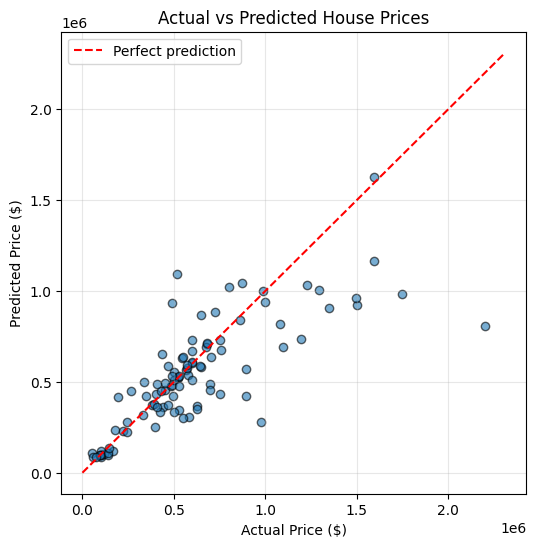

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(actual_dollars, preds_dollars, alpha=0.6, edgecolor="k")
lims = [0, max(actual_dollars.max(), preds_dollars.max()) * 1.05]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 16: Save the Trained Model

**Purpose:** Export the trained multimodal model so it can be reloaded later
and used to predict prices for new houses (given their tabular data and
photos) without retraining.

In [15]:
model.save("multimodal_house_price_model.keras")
print("Model saved to multimodal_house_price_model.keras")

Model saved to multimodal_house_price_model.keras


## Conclusion & Results

**What was built:**
A multimodal regression model that predicts house prices by fusing two
learned feature representations:
- A **CNN branch** that processes a 2x2 montage of each house's bathroom,
  bedroom, frontal, and kitchen photos
- An **MLP branch** that processes tabular data (bedrooms, bathrooms, area,
  one-hot encoded zip code)

The two branches' outputs are concatenated (**feature fusion**) and passed
through a small regression head to output a single predicted price.

**Results (see the printed output in Step 14 above for your exact run's numbers):**
- MAE: the average dollar error of predictions on the held-out test set
- RMSE: penalizes larger mistakes more heavily than MAE
- Both are also reported as a percentage of the mean test-set house price for
  easier interpretation

**Why this is a genuinely multimodal approach (not just two models bolted together):**
- Both branches are trained **jointly** — gradients from the final price
  prediction flow back through both the CNN and the MLP, so each branch
  learns representations specifically useful for predicting price *in
  combination with* the other modality, not in isolation.

**Known limitations of this dataset/approach:**
- Only 535 houses total is small for a CNN — expect the visual branch to add
  a smaller boost than it would with a bigger image dataset.
- The 2x2 montage approach is simple and fast, but loses some detail
  compared to giving each of the 4 photos its own dedicated CNN branch.

**Possible next steps:**
- Give each of the 4 room images its own CNN branch instead of one combined
  montage, then concatenate all of them with the tabular branch.
- Use transfer learning (e.g. a pretrained ResNet/EfficientNet as a frozen
  feature extractor) instead of training a CNN from scratch.
- Try data augmentation (flips, rotations, brightness jitter) on the images
  to reduce overfitting given the small dataset size.
- Log-transform the price target, which often stabilizes training for
  right-skewed price distributions.
